# FIT5196 Assessment 1 - EDA

---



#### Group64:
Member 1: Hao Xie (32613571), hxie0035@student.monash.edu, Contribution

Member 2: Yilin Shen, (34754954), yshe0132@student.monash.edu, EDA Visualization

...

---

### Table of Content

1. Load, parse and merge data files
2. EDA
3. Key insights and research
1.   List item
2.   List item





# 1. Load, parse and merge data files

In [105]:
# Import all the modules
import json
import re

import pandas as pd
import numpy as np

1. Load and Parse the XML file

In [106]:
# pd.read_xmlparses the xml into dataframe directly
df_xml = pd.read_xml('group_64.xml', encoding='utf-8')
print("XML shape:", df_xml.shape)
print(df_xml.columns.tolist())

XML shape: (14720, 18)
['PostID', 'UserID', 'secret', 'server', 'title', 'ispublic', 'isfriend', 'isfamily', 'farm', 'City', 'Country', 'Post_date', 'Taken_date', 'tags', 'latitude', 'longitude', 'description', 'min_taken_date']


2. Load and Parse the JSON File

In [107]:
# json.load() reads the file into a Python list of dicts; pd.DataFrame converts it
with open('group_64.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df_json = pd.DataFrame(data)
print("JSON shape:", df_json.shape)
print(df_json.head())

JSON shape: (29440, 18)
         PostID        UserID      secret   server  \
0  4.931549e+10  95897158@N02  1cb85fc603  65535.0   
1  4.931618e+10  16057556@N07  e49e95d2cb  65535.0   
2  4.931592e+10  39414578@N03  805b4e01fb  65535.0   
3  4.931592e+10  39414578@N03  8618800c33  65535.0   
4  4.931613e+10  39414578@N03  2bcce66ae7  65535.0   

                                               title  ispublic  isfriend  \
0      Een damesfiets opgeknapt voor mijn oude dag .       1.0       0.0   
1  TC-LJA - 2015 build Boeing B777-3F2ER, inbound...       1.0       0.0   
2                                 New Years Day Dip.       1.0       0.0   
3                                 New Years Day Dip.       1.0       0.0   
4                                 New Years Day Dip.       1.0       0.0   

   isfamily  farm City Country            Post date           Taken date  \
0       0.0  66.0  NaN     NaN  2020-01-02 13:58:04  2020-01-02 00:12:05   
1       0.0  66.0  NaN     NaN  2020-01-02

3. Schema Alignment - Rename Columns and Enforce Data Types

In [108]:
# Rename JSON columns so they match the XML naming convention (underscores)
df_json = df_json.rename(columns = {
    'Post date': 'Post_date',
    'Taken date': 'Taken_date'
})
dtype_mapping = {
    'PostID': 'Int64',
    'UserID': 'string',
    'secret': 'string',
    'server': 'Int64',
    'title': 'string',
    'ispublic': 'Int64',
    'isfriend': 'Int64',
    'isfamily': 'Int64',
    'farm': 'Int64',
    'City': 'string',
    'Country': 'string',
    'tags': 'string',
    'description': 'string'
}
# Apply type casting to both DataFrames
datetime_cols = ['Post_date', 'Taken_date', 'min_taken_date']
# Convert date coulmns to proper datetime objects
df_json = df_json.astype(dtype_mapping)
df_xml = df_xml.astype(dtype_mapping)
for col in datetime_cols:
    df_json[col] = pd.to_datetime(df_json[col])
    df_xml[col] = pd.to_datetime(df_xml[col])

4. Merge (Concatenate) the Two Datasets

In [109]:

# Merge (Concatenate) the Two Datasets
df_merged = pd.concat([df_xml, df_json], ignore_index = True)
print(df_merged.shape)

(44160, 18)


5. Duplication

In [110]:

# 5a. Remove duplicate rows across all columns
df_merged = df_merged.drop_duplicates()
print(df_merged.shape)



(29565, 18)


In [111]:
# Inspect remaining PostID-level duplicates
dup_count = df_merged['PostID'].duplicated().sum()
print(dup_count)


29


Result show 29 duplicate rows remaining after drop duplicates

In [112]:
# Investigation: duplicates differ only in min_taken_date
duplicates = df_merged[df_merged['PostID'].duplicated(keep=False)]
sample_id = duplicates['PostID'].iloc[0]
print(df_merged[df_merged['PostID'] == sample_id])

           PostID        UserID      secret  server  \
80    49384552911  60505704@N04  17b58f9425   65535   
3546  49384552911  60505704@N04  17b58f9425   65535   

                                                  title  ispublic  isfriend  \
80    Tyrers Coaches, Adlington YN57FYV at Farnworth...         1         0   
3546  Tyrers Coaches, Adlington YN57FYV at Farnworth...         1         0   

      isfamily  farm  City Country           Post_date          Taken_date  \
80           0    66  <NA>    <NA> 2020-01-14 13:32:49 2020-01-13 08:08:48   
3546         0    66  <NA>    <NA> 2020-01-14 13:32:49 2020-01-13 08:08:48   

                                                   tags   latitude  longitude  \
80    scaniak230ub,tyrerscoaches,adlington,farnworth...  53.548904  -2.394311   
3546  scaniak230ub,tyrerscoaches,adlington,farnworth...  53.548904  -2.394311   

                                   description min_taken_date  
80    New to Nottingham City Transport as 304.     20

Output shows the two identical rows only differs in min_taken_date, we can resolve by keeping the record with the earliest min_taken_date

In [113]:
df_merged = df_merged.sort_values('min_taken_date', ascending=True)
df_merged = df_merged.drop_duplicates(subset=['PostID'], keep='first')
df_merged = df_merged.reset_index(drop=True)
print(df_merged.shape)



(29536, 18)


Verify: no remaining PostID duplicates

In [114]:
assert df_merged['PostID'].duplicated().sum() == 0, "PostID duplicates still exist!"

6. Text Cleaning (Regular Expressions - applied only to text columns)

In [115]:
# Define the target text columns (as required by the spec)
text_cols = ['title', 'City', 'Country', 'tags', 'description']


Define  regex patterns for efficiency (compiled first and reuse it later)

In [116]:
# XML/HTML pattern: Marches tags like <br>, <p class="x", </div>, dtc.
RE_HTML_TAGS = re.compile(r'<[^>]+>')

In [117]:
# Match emojis, pictographs, zero-width joiners, and variation selectors.
RE_EMOJI = re.compile(
    '['
    '\U0001F600-\U0001F64F'   # Emoticons (smileys, gestures)
    '\U0001F300-\U0001F5FF'   # Miscellaneous Symbols and Pictographs
    '\U0001F680-\U0001F6FF'   # Transport and Map Symbols
    '\U0001F1E0-\U0001F1FF'   # Regional Indicator Symbols (flags)
    '\U0001F900-\U0001F9FF'   # Supplemental Symbols and Pictographs
    '\U0001FA00-\U0001FA6F'   # Chess Symbols
    '\U0001FA70-\U0001FAFF'   # Symbols and Pictographs Extended-A
    '\U00002702-\U000027B0'   # Dingbats
    '\U00002600-\U000026FF'   # Miscellaneous Symbols
    '\U0000FE00-\U0000FE0F'   # Variation Selectors
    '\U0000200D'              # Zero Width Joiner
    '\U00002300-\U000023FF'   # Miscellaneous Technical (some emoji)
    '\U0000200C-\U0000200D'   # Zero Width Non-Joiner + Joiner
    '\U000000A9'              # Copyright symbol (sometimes rendered as emoji)
    '\U000000AE'              # Registered symbol
    '\U0000203C'              # Double exclamation mark
    '\U00002049'              # Exclamation question mark
    '\U000020E3'              # Combining Enclosing Keycap
    '\U00002122'              # Trade mark sign
    '\U00002139'              # Information source
    '\U00002194-\U000021AA'   # Arrows (sometimes emoji)
    '\U000025AA-\U000025AB'   # Small squares
    '\U000025B6'              # Play button
    '\U000025C0'              # Reverse button
    '\U000025FB-\U000025FE'   # Medium squares
    '\U00003030'              # Wavy dash
    '\U0000303D'              # Part alternation mark
    '\U00003297'              # Circled ideograph congratulation
    '\U00003299'              # Circled ideograph secret
    ']+',
    flags=re.UNICODE
)

In [118]:
# non-Latin script Pattern
# Allowed: Latin script (Basic Latin, Latin-1 Supplement, Latin Extended-A/B,
#          Latin Extended Additional), combining diacritical marks,
#          digits, whitespace, ASCII punctuation, common Unicode punctuation, and @.

RE_NON_LATIN = re.compile(
    r'[^'
    r'a-zA-Z'                 # Basic Latin letters
    r'\u00C0-\u00D6'          # Latin-1 Supplement (upper accented: A-grave to O-diaeresis)
    r'\u00D8-\u00F6'          # Latin-1 Supplement (O-stroke to o-diaeresis)
    r'\u00F8-\u00FF'          # Latin-1 Supplement (o-stroke to y-diaeresis)
    r'\u0100-\u017F'          # Latin Extended-A (e.g., macrons, carons)
    r'\u0180-\u024F'          # Latin Extended-B (e.g., Croatian, Romanian digraphs)
    r'\u1E00-\u1EFF'          # Latin Extended Additional (e.g., Vietnamese)
    r'\u0300-\u036F'          # Combining Diacritical Marks (accents, tildes, etc.)
    r'\s'                     # Whitespace (space, tab, newline)
    r'0-9'                    # Digits
    r'!"#$%&\'()*+,\-./:;<=>?@\[\\\]^_`{|}~'   # ASCII punctuation
    r'\u2010-\u2027'          # General Punctuation (en-dash, em-dash, quotes, etc.)
    r'\u2030-\u205E'          # Per-mille, prime, brackets, etc.
    r']'
)

In [119]:
def clean_text(text):
    """
    Clean a single text value by sequentially removing:
      1. XML/HTML tags (e.g., <br>, <a href="...">)
      2. Emojis and pictographic symbols
      3. Non-Latin characters (Japanese, Chinese, Russian Cyrillic, etc.)
    Retains: Latin script (including European diacritics), digits, whitespace,
             punctuation, and the @ symbol.
    Returns the original value unchanged if it is not a string (e.g., NaN).
    """
    if not isinstance(text, str):
        return text
    # Step 1: Remove XML/HTML tags
    text = RE_HTML_TAGS.sub('', text)
    # Step 2: Remove emojis and associated joiners / variation selectors
    text = RE_EMOJI.sub('', text)
    # Step 3: Remove non-Latin characters
    text = RE_NON_LATIN.sub('', text)
    return text

# Apply cleaning to all string/object columns
string_cols = df_merged.select_dtypes(include=['string', 'object']).columns.tolist()
for col in string_cols:
    df_merged[col] = df_merged[col].map(clean_text)

7. Lowercase Transformation

In [120]:
# .str.lower() automatically preserves NaN values
df_merged[text_cols] = df_merged[text_cols].apply(lambda x: x.str.lower())
print(df_merged[text_cols].head(10))

                                              title               City  \
0                         welcome to the new decade            glasgow   
1                               new year's day swim                NaN   
2             collieston harbour - 1st january 2020                NaN   
3                                      old graffiti           grantham   
4  day breaking over aberdeen lighthoose 02/01/2020  aberdeen/scotland   
5                           trentham fairy - wishes     stoke on trent   
6                                               NaN                NaN   
7                                               NaN                NaN   
8                 n182 lap - 1995 alfa romeo 155 v6    buckinghamshire   
9    jda 74 - 1950 reliant girder fork tricycle van    buckinghamshire   

          Country                                               tags  \
0  united kingdom              glasgow,scotland,uk,2020,newyearsday,   
1         ireland  frankfullard,fullard,c

8. Date Formatting - Standardise min_taken_date Display

In [121]:
# Standardise min_taken_date to a consistent string for output
df_merged['min_taken_date'] = (
    pd.to_datetime(df_merged['min_taken_date'])
    .dt.strftime('%Y-%m-%d %H:%M:%S')
)
# Convert min_taken_date back to datetime type
df_merged['min_taken_date'] = pd.to_datetime(df_merged['min_taken_date'])
print(df_merged['min_taken_date'])
print(df_merged.dtypes)

0       2020-01-01
1       2020-01-01
2       2020-01-01
3       2020-01-01
4       2020-01-01
           ...    
29531   2020-01-16
29532   2020-01-16
29533   2020-01-16
29534   2020-01-16
29535   2020-01-16
Name: min_taken_date, Length: 29536, dtype: datetime64[us]
PostID                     Int64
UserID                       str
secret                       str
server                     Int64
title                        str
ispublic                   Int64
isfriend                   Int64
isfamily                   Int64
farm                       Int64
City                         str
Country                      str
Post_date         datetime64[us]
Taken_date        datetime64[us]
tags                         str
latitude                 float64
longitude                float64
description                  str
min_taken_date    datetime64[us]
dtype: object


9. Null Value Handling

In [122]:
# Replace empty strings and whitespace-only strings with NaN
df_merged = df_merged.replace(r'^\s*$', np.nan, regex=True)

In [123]:
# Replace common null-like strings with NaN
null_like_values = ['none', 'null', 'na', 'n/a', 'None', 'NULL', 'NA', 'N/A', '']
df_merged = df_merged.replace(null_like_values, np.nan)
print(df_merged.isna().sum())

PostID                1
UserID                1
secret                1
server                1
title               865
ispublic              1
isfriend              1
isfamily              1
farm                  1
City              16144
Country           16342
Post_date             0
Taken_date            1
tags              10192
latitude              1
longitude             1
description       12657
min_taken_date        0
dtype: int64


10. Validation Checks (tageted to text columns)

In [124]:
# 10a. Check for remaining XML/HTML tags
def has_html_tags(text):
    if not isinstance(text, str):
        return False
    return bool(RE_HTML_TAGS.search(text))

In [125]:
html_counts = df_merged[string_cols].apply(lambda col: col.map(has_html_tags)).sum()
print("XML/HTML tags remaining:")
print(html_counts)
assert html_counts.sum() == 0, "XML/HTML tags still present!"

XML/HTML tags remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [126]:
# 10b. Check for remaining non-Latin characters
def has_non_latin(text):
    if not isinstance(text, str):
        return False
    return bool(RE_NON_LATIN.search(text))

non_latin_counts = df_merged[string_cols].apply(lambda col: col.map(has_non_latin)).sum()
print("Non-Latin characters remaining:")
print(non_latin_counts)
assert non_latin_counts.sum() == 0, "Non-Latin characters still present!"

Non-Latin characters remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [127]:
# 10c. Check for remaining emojis
def has_emoji(text):
    if not isinstance(text, str):
        return False
    return bool(RE_EMOJI.search(text))

emoji_counts = df_merged[string_cols].apply(lambda col: col.map(has_emoji)).sum()
print(f"Emoji characters remaining:\n{emoji_counts}")
assert emoji_counts.sum() == 0, "Emoji characters still present!"

Emoji characters remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [128]:
# 10d. Check no null-like string literals remain
null_like_check = ['None', 'none', 'NULL', 'null', 'NA', 'na',
                   'N/A', 'n/a', 'nan', 'NaN', '']
for col in df_merged.columns:
    matches = df_merged[col].isin(null_like_check).sum()
    if matches > 0:
        print(f"  Warning: Column '{col}' has {matches} null-like strings remaining")

In [129]:
# Convert the min_taken_date back to string format, as it needs to display 00:00:00
df_merged['min_taken_date'] = pd.to_datetime(df_merged['min_taken_date']).dt.strftime('%Y-%m-%d %H:%M:%S')
# 10e. Confirm date columns are not corrupted
print(df_merged[['Post_date', 'Taken_date', 'min_taken_date']].head(10).to_string())


            Post_date          Taken_date       min_taken_date
0 2020-01-01 11:11:15 2020-01-01 08:30:21  2020-01-01 00:00:00
1 2020-01-02 06:03:31 2020-01-01 13:53:33  2020-01-01 00:00:00
2 2020-01-02 17:48:19 2020-01-01 14:34:42  2020-01-01 00:00:00
3 2020-01-02 17:41:03 2020-01-02 12:41:41  2020-01-01 00:00:00
4 2020-01-02 17:03:09 2020-01-02 07:50:42  2020-01-01 00:00:00
5 2020-01-02 16:36:36 2020-01-01 14:43:42  2020-01-01 00:00:00
6 2020-01-02 16:20:59 2020-01-01 11:01:33  2020-01-01 00:00:00
7 2020-01-02 16:20:59 2020-01-01 11:16:28  2020-01-01 00:00:00
8 2020-01-02 15:56:17 2020-01-01 11:50:33  2020-01-01 00:00:00
9 2020-01-02 15:23:35 2020-01-01 11:33:17  2020-01-01 00:00:00


11. Rename columns to match sample output format

In [130]:

# The sample output file specifies exact column names with underscores and
# title-case formatting. Renaming to match exactly.
column_rename_map = {
    'PostID':         'Post_ID',
    'UserID':         'User_ID',
    'secret':         'Secret',
    'server':         'Server',
    'title':          'Title',
    'ispublic':       'Is_Public',
    'isfriend':       'Is_Friend',
    'isfamily':       'Is_Family',
    'farm':           'Farm',
    'City':           'City',
    'Country':        'Country',
    'Post_date':      'Post_Date',
    'Taken_date':     'Taken_Date',
    'tags':           'Tags',
    'latitude':       'Latitude',
    'longitude':      'Longitude',
    'description':    'Description',
    'min_taken_date': 'Min_Taken_Date'
}

df_merged = df_merged.rename(columns=column_rename_map)
print("Final columns:", df_merged.columns.tolist())

Final columns: ['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']


In [131]:
# 12. Export to csv
# Output with UTF-8 encoding and NaN representation as required by the spec
# df_merged.to_csv('Group64_dataset.csv', index=False, encoding='utf-8', na_rep='NaN')
df_merged.shape

(29536, 18)

## 2. EDA


In [132]:
# load package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
# read the csv file
df = pd.read_csv("Group64_dataset.csv")

### 2.1 Dataset overview

In [133]:
print(df.shape)
print("User:", df['User_ID'].nunique())
print("Country:", df['Country'].nunique())
print("City:", df['City'].nunique())
df.head(3)

(29536, 18)
User: 1904
Country: 109
City: 517


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,4.930880e+10,57511216@N04,9b81878a97,65535.0,welcome to the new decade,1.0,0.0,0.0,66.0,glasgow,united kingdom,2020-01-01 11:11:15,2020-01-01 08:30:21,"glasgow,scotland,uk,2020,newyearsday,",55.855611,-4.257634,NaN,2020-01-01 00:00:00
1,4.931384e+10,44288006@N03,521c3904e9,65535.0,new year's day swim,1.0,0.0,0.0,66.0,NaN,ireland,2020-01-02 06:03:31,2020-01-01 13:53:33,"frankfullard,fullard,candid,street,portrait,fu...",54.012245,-10.021827,the roaring twenties got a warm west of irelan...,2020-01-01 00:00:00
2,4.931737e+10,67872859@N00,0b5961d66c,65535.0,collieston harbour - 1st january 2020,1.0,0.0,0.0,66.0,NaN,NaN,2020-01-02 17:48:19,2020-01-01 14:34:42,NaN,57.346200,-1.935339,compair light room changes,2020-01-01 00:00:00


In [134]:
print('=== Data Types ===')
print(df.dtypes)

print('=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
Post_ID           float64
User_ID               str
Secret                str
Server            float64
Title                 str
Is_Public         float64
Is_Friend         float64
Is_Family         float64
Farm              float64
City                  str
Country               str
Post_Date             str
Taken_Date            str
Tags                  str
Latitude          float64
Longitude         float64
Description           str
Min_Taken_Date        str
dtype: object
=== Descriptive Statistics ===


,Post_ID,Server,Is_Public,Is_Friend,Is_Family,Farm,Latitude,Longitude
count,2.953500e+04,29535.000000,29535.0,29535.0,29535.0,29535.000000,29535.000000,29535.000000
mean,4.959309e+10,65341.572169,1.0,0.0,0.0,65.805282,53.380217,-0.879752
std,1.119406e+09,3521.955527,0.0,0.0,0.0,3.545538,1.313043,3.209230
min,2.176472e+09,0.000000,1.0,0.0,0.0,0.000000,52.000444,-10.460851
25%,4.934771e+10,65535.000000,1.0,0.0,0.0,66.000000,52.396797,-2.231340
50%,4.937880e+10,65535.000000,1.0,0.0,0.0,66.000000,52.941955,-1.314926
75%,4.949810e+10,65535.000000,1.0,0.0,0.0,66.000000,53.740872,-0.425748
max,5.208909e+10,65535.000000,1.0,0.0,0.0,66.000000,59.999071,9.999166


### 2.2 Univariate analysis

2.2.1 Missing Value


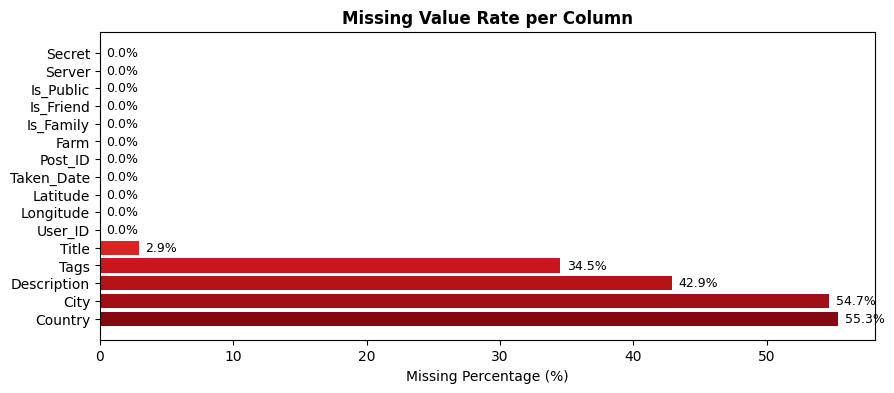

In [135]:
# missing value
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=sns.color_palette('Reds_r', len(missing_pct)))
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Value Rate per Column', fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.grid(False)
plt.savefig('fig1_missing_values.png', bbox_inches='tight')
plt.show()

2.2.2 Temporal Analysis

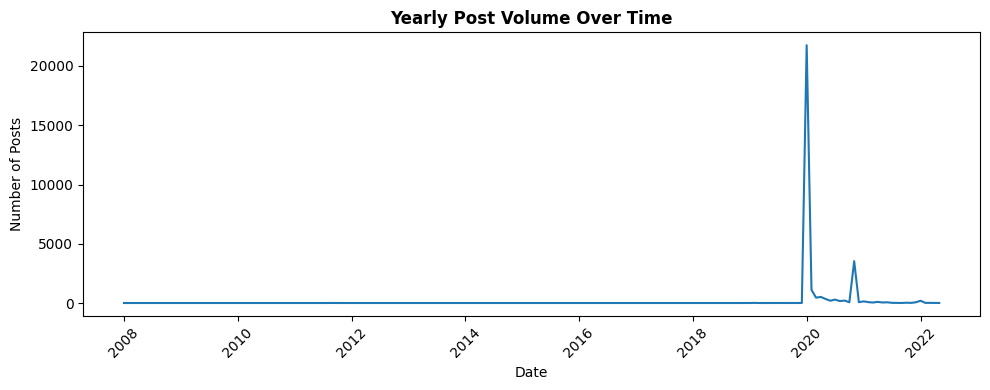

In [136]:
# Post time analysis
# Parse dates
df['Post_Date']  = pd.to_datetime(df['Post_Date'],  errors='coerce')
df['Taken_Date'] = pd.to_datetime(df['Taken_Date'], errors='coerce')

# Reorder Monthly
df['year_month'] = df['Post_Date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
monthly_counts.index = monthly_counts.index.to_timestamp()

# Monthly-post plot
plt.figure(figsize=(10,4))
plt.grid(False)
plt.plot(monthly_counts.index, monthly_counts.values)

plt.title('Yearly Post Volume Over Time', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Posts')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig3a_yearly_temporal_analysis.png', bbox_inches='tight')
plt.show()

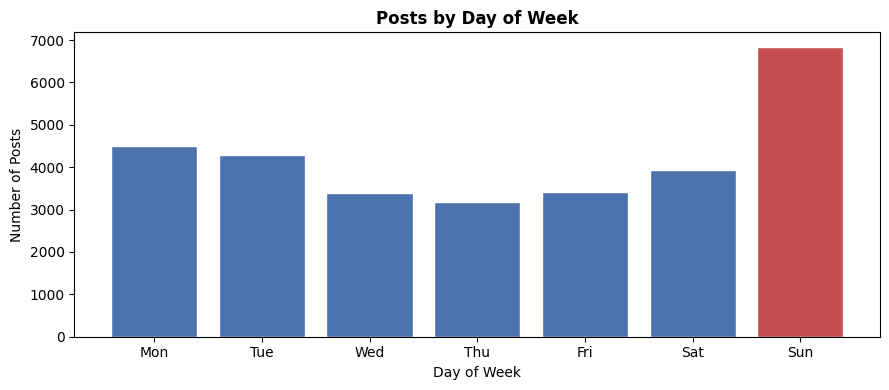

In [137]:
# Weekly post analysis
df['post_week']  = df['Post_Date'].dt.dayofweek   # 0=Mon
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(9, 4))

# Day of Week
dow_counts = df['post_week'].value_counts().sort_index()
colors_dow = ['#C44E52' if d == 6 else '#4C72B0' for d in dow_counts.index]
ax.bar([dow_names[i] for i in dow_counts.index],
            dow_counts.values, color=colors_dow, edgecolor='white')
ax.set_title('Posts by Day of Week', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Posts')

plt.grid(False)
plt.tight_layout()
plt.savefig('fig3c_weekly_analysis.png', bbox_inches='tight')
plt.show()

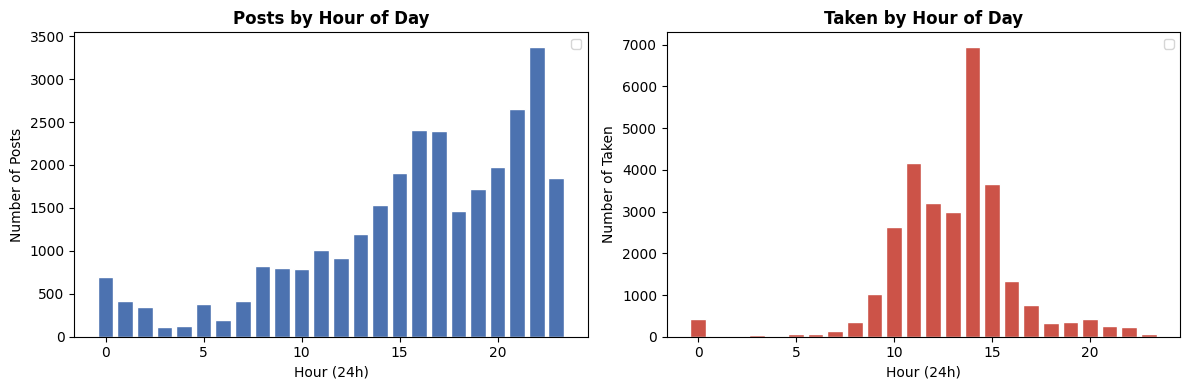

In [138]:
# Taken time vs Post time
df['taken_hour'] = df['Taken_Date'].dt.hour
df['post_hour']  = df['Post_Date'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Hourly post
hour_counts = df['post_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
           color='#4C72B0', edgecolor='white')
axes[0].set_title('Posts by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (24h)')
axes[0].set_ylabel('Number of Posts')
axes[0].legend(fontsize=9)

# ── Hourly taken
taken_counts = df['taken_hour'].value_counts().sort_index()
axes[1].bar(taken_counts.index, taken_counts.values,
            color="#CC5348", edgecolor='white')
axes[1].set_title('Taken by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of Taken')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3b_postandtaken_analysis.png', bbox_inches='tight')
plt.show()

2.2.3 Geographic Distribution

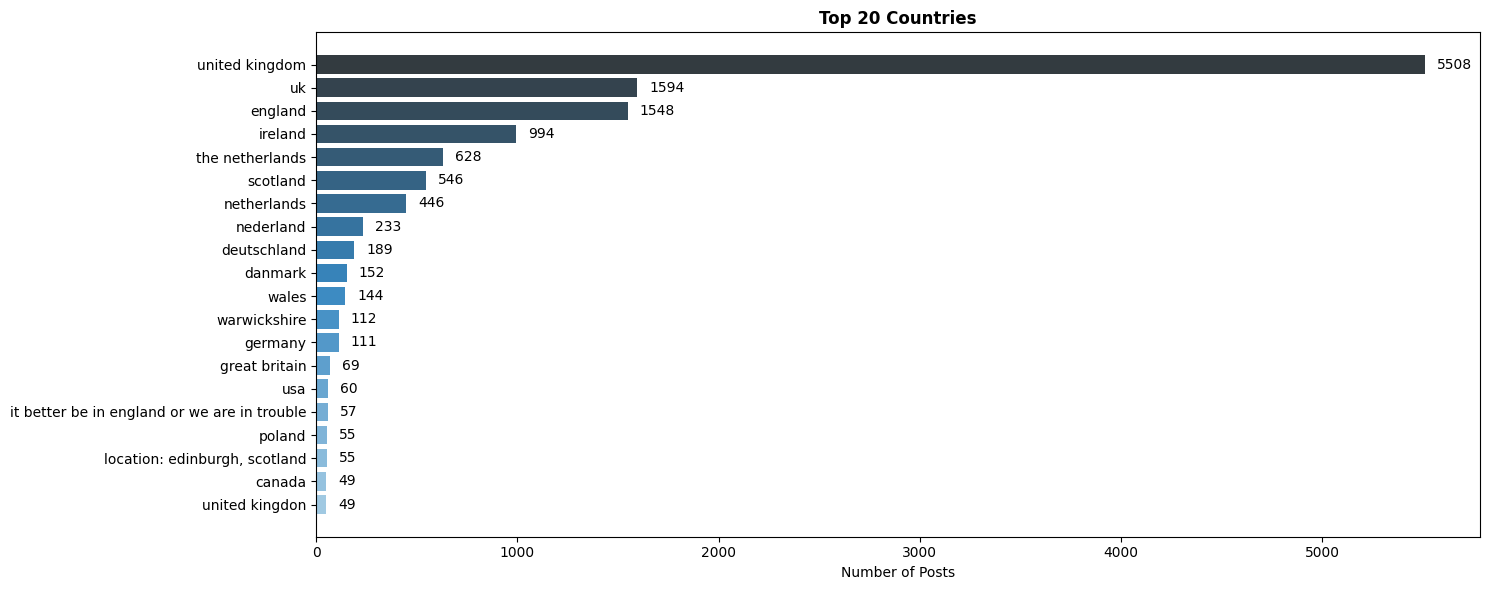

In [139]:
# Top20 Countries
fig, ax = plt.subplots(figsize=(15, 6))

country_counts = df['Country'].str.lower().str.strip().value_counts().head(20)
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
             color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Countries', fontweight='bold')
ax.set_xlabel('Number of Posts')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 60,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.grid(False)
plt.tight_layout()
plt.savefig('fig5a_top20_countries_geographic.png', bbox_inches='tight')
plt.show()

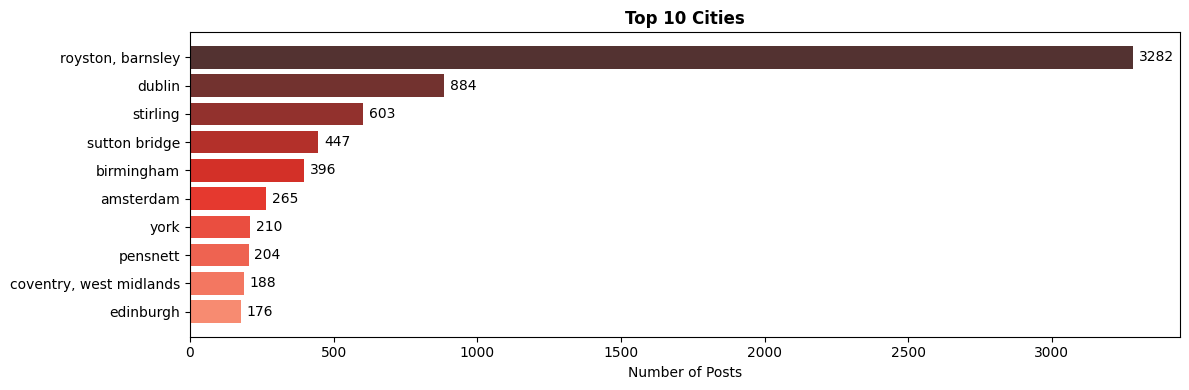

In [140]:
# Top10 Cities
fig, ax = plt.subplots(figsize=(12, 4))

city_counts = df['City'].str.lower().str.strip().value_counts().head(10)
bars = ax.barh(city_counts.index[::-1], city_counts.values[::-1],
             color=sns.color_palette('Reds_d', 10))
ax.set_title('Top 10 Cities', fontweight='bold')
ax.set_xlabel('Number of Posts')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 20,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.grid(False)
plt.tight_layout()
plt.savefig('fig5b_top10_cities_geographic.png', bbox_inches='tight')
plt.show()

2.2.4 Tag Analysis

Average tags per post: 11.45


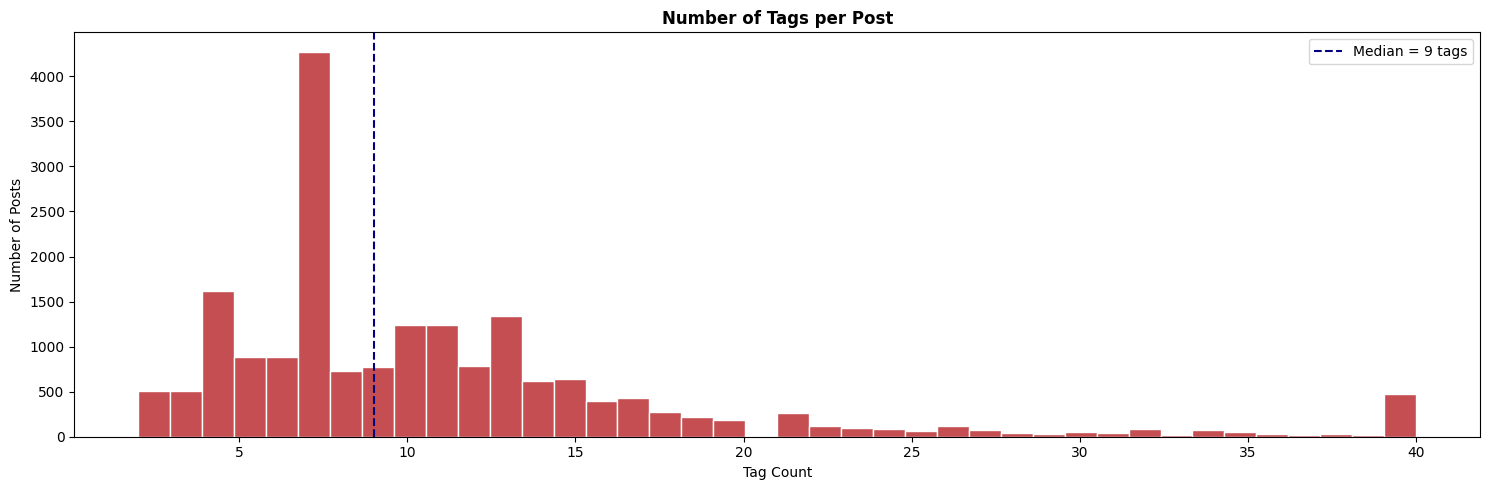

In [141]:
# 6. Tags Analysis — User Engagement via Tagging
df_tags = df[df['Tags'].notna()].copy()
df_tags['tag_list'] = df_tags['Tags'].str.strip('[]').str.replace("'", "").str.split(',')
df_tags['tag_count'] = df_tags['tag_list'].str.len()
avg_tags = df_tags['tag_count'].mean()
print(f'Average tags per post: {avg_tags:.2f}')

# All tags flattened
all_tags = [t.strip() for sublist in df_tags['tag_list']
            for t in sublist if t.strip()]
tag_freq = Counter(all_tags).most_common(20)
tag_words, tag_vals = zip(*tag_freq)

fig, ax = plt.subplots(figsize=(15, 5))

# Tag count distribution
ax.hist(df_tags['tag_count'].clip(upper=40), bins=40,
             color='#C44E52', edgecolor='white')
ax.axvline(df_tags['tag_count'].median(), color='navy',
                linestyle='--', label=f'Median = {df_tags["tag_count"].median():.0f} tags')
ax.set_title('Number of Tags per Post', fontweight='bold')
ax.set_xlabel('Tag Count')
ax.set_ylabel('Number of Posts')
ax.legend()

plt.grid(False)
plt.tight_layout()
plt.savefig('fig5c_geo_scatter.png', bbox_inches='tight')
plt.show()


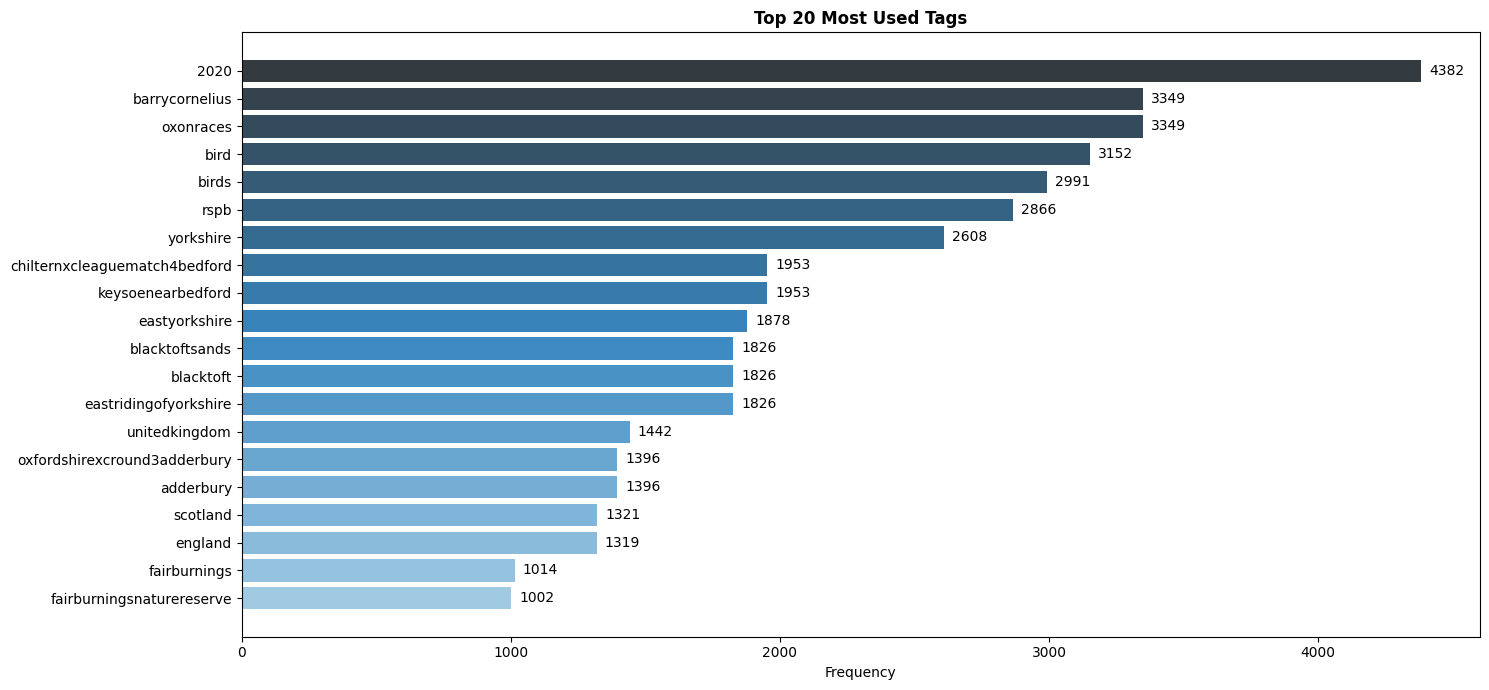

In [142]:
# Top 20 tags
fig, ax = plt.subplots(figsize=(15, 7))

bars = ax.barh(list(tag_words)[::-1], list(tag_vals)[::-1],
             color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Most Used Tags', fontweight='bold')
ax.set_xlabel('Frequency')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 30,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('fig6_tags_analysis.png', bbox_inches='tight')
plt.show()

2.2.5 Description Length analysis

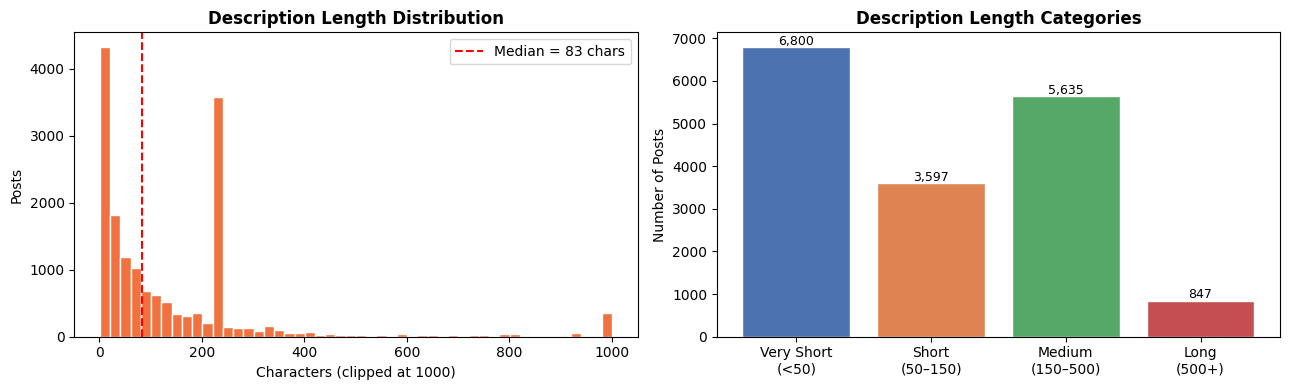

Finding: 57% of posts with descriptions are "Very Short" (<50 chars), showing most users prefer minimal text. Only 14% write long descriptions (500+ chars).


In [143]:
# split the str in description
df_desc = df[df['Description'].notna()].copy()
df_desc['desc_len'] = df_desc['Description'].str.len()

# Categorise
bins   = [0, 50, 150, 500, np.inf]
labels = ['Very Short\n(<50)', 'Short\n(50–150)', 'Medium\n(150–500)', 'Long\n(500+)']
df_desc['desc_cat'] = pd.cut(df_desc['desc_len'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df_desc['desc_len'].clip(upper=1000), bins=50,
             color="#ED4B0BC7", edgecolor='white')
axes[0].axvline(df_desc['desc_len'].median(), color='red',
                linestyle='--',
                label=f'Median = {df_desc["desc_len"].median():.0f} chars')
axes[0].set_title('Description Length Distribution', fontweight='bold')
axes[0].set_xlabel('Characters (clipped at 1000)')
axes[0].set_ylabel('Posts')
axes[0].legend()

# Category bar
cat_counts = df_desc['desc_cat'].value_counts().reindex(labels)
axes[1].bar(cat_counts.index, cat_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('Description Length Categories', fontweight='bold')
axes[1].set_ylabel('Number of Posts')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig7_description_length.png', bbox_inches='tight')
plt.show()
print('Finding: 57% of posts with descriptions are "Very Short" (<50 chars),'
      ' showing most users prefer minimal text. Only 14% write long descriptions (500+ chars).')

### 2.3 Bivariate analysis

2.3.1 Upload delay analysis

Rows kept       : 29,248 / 29,536
Median delay    : 39.9 hours
Mean delay      : 1631.4 hours


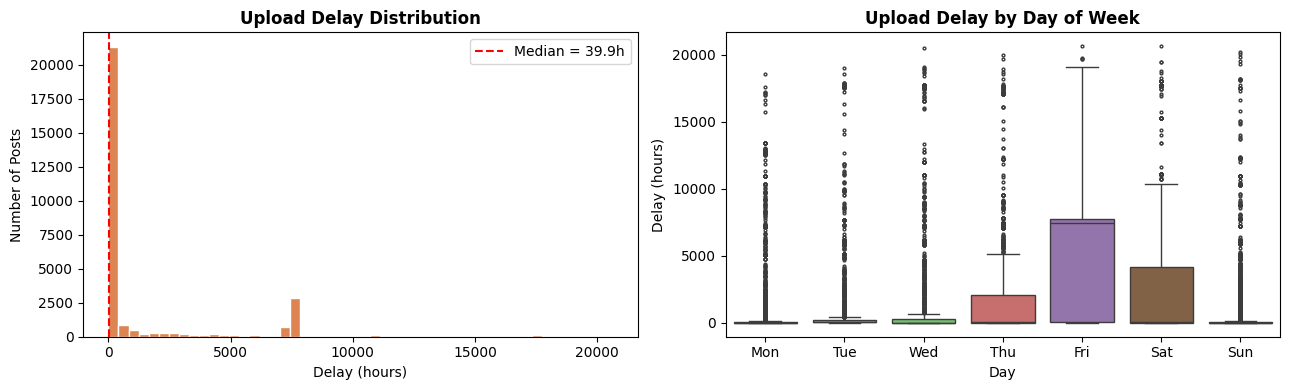

In [ ]:
# upload delay from taken to post

# 2. Compute delay in hours (whole frame)
# df["Delay_Hours"] = (
#     df["Post_Date"] - df["Taken_Date"]
# ).dt.total_seconds() / 3600

# # 3. How many negative / out-of-range rows are there BEFORE filtering?
# print(f"Negative delays : {(df['Delay_Hours'] < 0).sum():,}")

# # 4. Filter to Delay_Hours > 0 hours = photos posted within 30 days of being taken
# mask = df[df["Delay_Hours"] > 0]
# delays = df.loc[df["Delay_Hours"] > 0, "Delay_Hours"]
# print(f"Rows kept       : {len(delays):,} / {len(df):,}")

# # 5. Summary stats
# print(f"Median delay    : {delays.median():.1f} hours")
# print(f"Mean delay      : {delays.mean():.1f} hours")

# df['post_dow'] = df['Post_Date'].dt.dayofweek
# df['upload_delay_h'] = (df['Post_Date'] - df['Taken_Date']).dt.total_seconds() / 3600
# delay_clean = df['upload_delay_h'][(df['upload_delay_h'] >= 0)]  # within 30 days

df["Delay_Hours"] = (
    df["Post_Date"] - df["Taken_Date"]
).dt.total_seconds() / 3600

mask = df[df["Delay_Hours"] > 0]
delay_clean = df.loc[df["Delay_Hours"] > 0, "Delay_Hours"]
print(f"Rows kept       : {len(delay_clean):,} / {len(df):,}")

# 5. Summary stats
print(f"Median delay    : {delay_clean.median():.1f} hours")
print(f"Mean delay      : {delay_clean.mean():.1f} hours")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(delay_clean, bins=50, color='#DD8452', edgecolor='white')
axes[0].set_title('Upload Delay Distribution', fontweight='bold')
axes[0].set_xlabel('Delay (hours)')
axes[0].set_ylabel('Number of Posts')
axes[0].axvline(delay_clean.median(), color='red',
                linestyle='--', label=f'Median = {delay_clean.median():.1f}h')
axes[0].legend()

# Box plot by day of week
delay_df = df[['post_dow', 'upload_delay_h']].copy()
delay_df = delay_df[(delay_df['upload_delay_h'] >= 0)]
                    
delay_df['Day'] = delay_df['post_dow'].map(dict(enumerate(dow_names)))
order = dow_names
sns.boxplot(data=delay_df, x='Day', y='upload_delay_h',
            order=order, ax=axes[1], palette='muted', fliersize=2)
axes[1].set_title('Upload Delay by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Delay (hours)')

plt.tight_layout()
plt.savefig('fig4_upload_delay.png', bbox_inches='tight')
plt.show()

2.3.2  Location map

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

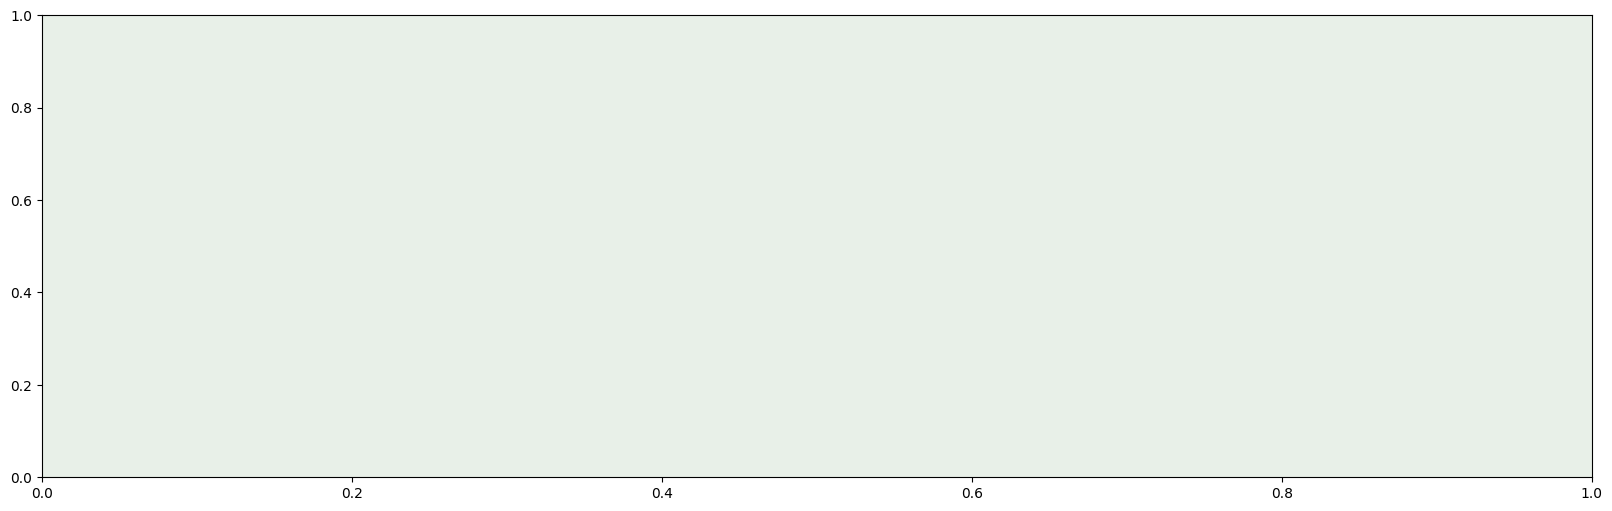

In [ ]:
# europe map
import geopandas as gpd
# ── Geospatial scatter plot
geo = df[df['Latitude'].notna() & df['Longitude'].notna()].copy()
fig, ax = plt.subplots(figsize=(20, 6))

# Google Maps-style colors
ax.set_facecolor("#e8f0e8")          # water/background = light blue-green

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
europe = world[world["REGION_UN"] == "Europe"]
europe.plot(
    ax=ax,
    color="#f5f5dc",        # land = warm beige (Google Maps land color)
    edgecolor="#c0c0c0",    # borders = soft gray
    linewidth=0.5
)

# Original la&long titude
scatter = ax.scatter(geo['Longitude'], geo['Latitude'],
                     alpha=0.15, s=5, c='#4C72B0')
ax.set_title('Geospatial Distribution of Posts', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-12, 12)
ax.set_ylim(50, 62)

mean_lon = df['Longitude'].mean()
mean_lat = df['Latitude'].mean()

plt.axvline(mean_lon, linestyle='--')
plt.axhline(mean_lat, linestyle='--')

plt.grid(False)
plt.tight_layout()
plt.savefig('fig_geo_scatter.png', bbox_inches='tight')
plt.show()

### 2.4 Multivariate analysis

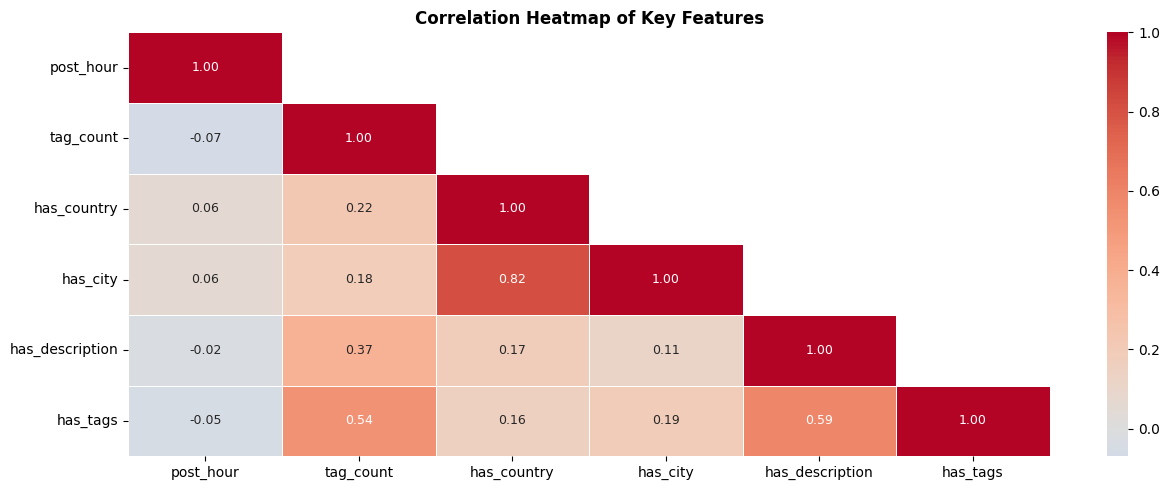

In [ ]:
# Correlation Heatmap — Numerical Features
# Add engineered features for correlation
df['has_tags']        = df['Tags'].notna().astype(int)
df['has_description'] = df['Description'].notna().astype(int)
df['has_city']        = df['City'].notna().astype(int)
df['has_country']     = df['Country'].notna().astype(int)
# df['tag_count']       = df['Tags'].str.strip(',').str.split(',').str.len().fillna(0)
df['tag_count'] = (
    df['Tags']
    .fillna('')
    .str.strip(',')
    .str.split(',')
    .apply(lambda x: 0 if x == [''] else len(x))
)

corr_cols = [
    'post_hour', 'tag_count',
    'has_country', 'has_city',
    'has_description', 'has_tags']

corr = df[corr_cols].corr()
df_corr = df.drop(columns=['post_dow'])

fig, ax = plt.subplots(figsize=(13, 5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap of Key Features', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 3.Key insights and research questions

### 3.1 key findings

In [ ]:
# 4.1 Geographical Concentration
# Coordinate ranges and means
import json
import re

import pandas as pd
import numpy as np

df = pd.read_csv("Group64_dataset.csv")
lat = df['Latitude']
lon = df['Longitude']
print(f"Mean latitude:  {lat.mean():.2f}  (claim 53.38)")
print(f"Mean longitude: {lon.mean():.2f}  (claim -0.88)")
print(f"Latitude range:  {lat.min():.1f} to {lat.max():.1f}  (claim 52.0 to 60.0)")
print(f"Longitude range: {lon.min():.1f} to {lon.max():.1f}  (claim -10.5 to 10.0)")

# Country-labelled subset and UK share
labelled = df[df['Country'].notna() & (df['Country'].astype(str).str.strip() != '')]
print(f"\nRecords with a country label: {len(labelled)}  (claim 13,194)")

# Any country string containing a UK-linked keyword
uk_pattern = r'united kingdom|^uk$|\buk\b|england|scotland|wales|britain|northern ireland'
uk_mask = labelled['Country'].astype(str).str.lower().str.contains(uk_pattern, regex=True, na=False)
print(f"UK-linked records: {uk_mask.sum()}  "
      f"({uk_mask.mean() * 100:.1f}% of labelled)  (claim 9,630, >73%)")
print(f"Distinct UK variant strings: {labelled.loc[uk_mask, 'Country'].nunique()}  (claim 43)")

Mean latitude:  53.38  (claim 53.38)
Mean longitude: -0.88  (claim -0.88)
Latitude range:  52.0 to 60.0  (claim 52.0 to 60.0)
Longitude range: -10.5 to 10.0  (claim -10.5 to 10.0)

Records with a country label: 13194  (claim 13,194)
UK-linked records: 9662  (73.2% of labelled)  (claim 9,630, >73%)
Distinct UK variant strings: 44  (claim 43)


In [ ]:
# 4.2 Country Labels
# Total unique country labels (normalise whitespace + case first)
c_norm = df['Country'].astype(str).str.lower().str.strip()
print(f"Unique country labels (raw): {df['Country'].nunique()}  (claim 109)")

# Specific UK variants cited in the report
for variant in ['united kingdom', 'uk', 'england', 'scotland', 'wales', 'great britain']:
    n = (c_norm == variant).sum()
    print(f"  '{variant}': {n}")

# Trailing-whitespace example: 'scotland ' vs 'scotland'
raw = df['Country'].astype(str)
print(f"\n  'scotland ' (trailing space): {(raw == 'scotland ').sum()}  (claim 47)")

# Full-sentence and metadata-style oddities
print(f"  'it better be in England or we are in trouble': "
      f"{(raw == 'it better be in England or we are in trouble').sum()}  (claim 57)")
print(f"  'location: edinburgh, scotland': "
      f"{(raw == 'location: edinburgh, scotland').sum()}  (claim 55)")

# Netherlands variants
print(f"\n  'the Netherlands': {(raw == 'the Netherlands').sum()}")
print(f"  'Nederland':       {(raw == 'Nederland').sum()}")

# Most common 20 labels, for a sanity eyeball
print(f"\nTop 20 raw Country labels:\n{df['Country'].value_counts().head(20)}")

Unique country labels (raw): 109  (claim 109)
  'united kingdom': 5508
  'uk': 1594
  'england': 1548
  'scotland': 546
  'wales': 144
  'great britain': 69

  'scotland ' (trailing space): 47  (claim 47)
  'it better be in England or we are in trouble': 0  (claim 57)
  'location: edinburgh, scotland': 55  (claim 55)

  'the Netherlands': 0
  'Nederland':       0

Top 20 raw Country labels:
Country
united kingdom                                  5473
uk                                              1560
england                                         1545
ireland                                          994
the netherlands                                  628
scotland                                         499
netherlands                                      446
nederland                                        233
deutschland                                      189
danmark                                          152
wales                                            144
warwickshire   

In [ ]:
# 4.3 City Ranking 
# Filter rows where City is 'royston, barnsley'
royston = df[df['City'] == 'royston, barnsley']

# Count total posts and unique users
print(f"Total posts from 'royston, barnsley': {len(royston)}")
print(f"Unique users: {royston['User_ID'].nunique()}")

# Show post count per user
print(f"\nPosts per user:\n{royston['User_ID'].value_counts()}")

Total posts from 'royston, barnsley': 3282
Unique users: 1

Posts per user:
User_ID
20747318@N08    3282
Name: count, dtype: int64


In [ ]:
# 4.4 User Activity Distribution
uc = df['User_ID'].value_counts()
n_users = uc.size

print(f"Unique users: {n_users}")
print(f"Users who posted exactly once: {(uc == 1).sum()} "
      f"({(uc == 1).mean() * 100:.1f}%)  (claim 636, 33.4%)")
print(f"Median posts per user: {uc.median()}  (claim 3)")
print(f"Top 10 users' share of all records: "
      f"{uc.head(10).sum() / len(df) * 100:.1f}%  (claim 44.1%)")
print(f"Most active user post count: {uc.iloc[0]} "
      f"({uc.iloc[0] / len(df) * 100:.1f}% of corpus)  (claim 3,512, 11.9%)")
print(f"\nTop 10 users:\n{uc.head(10)}")

Unique users: 1904
Users who posted exactly once: 636 (33.4%)  (claim 636, 33.4%)
Median posts per user: 3.0  (claim 3)
Top 10 users' share of all records: 44.1%  (claim 44.1%)
Most active user post count: 3512 (11.9% of corpus)  (claim 3,512, 11.9%)

Top 10 users:
User_ID
124580380@N04    3512
159968055@N03    3349
20747318@N08     3282
38327481@N03      701
63308252@N06      600
156618643@N02     599
73574431@N06      276
39415781@N06      273
60535836@N02      228
8921597@N03       204
Name: count, dtype: int64


In [ ]:
# 4.5 Missing Value in Country and City
# Coordinate columns: near-complete
for col in ['Latitude', 'Longitude']:
    miss = df[col].isna().sum()
    print(f"{col}: {miss} missing  ({(1 - miss / len(df)) * 100:.2f}% populated)")

# City / Country: mostly missing
for col in ['City', 'Country']:
    miss = df[col].isna().sum()
    print(f"{col}: {miss} missing  ({miss / len(df) * 100:.1f}% missing)")

# Expected per report: City 16,144 (54.7%), Country 16,342 (55.3%), Lat/Lon 1 each (99.99%)

Latitude: 1 missing  (100.00% populated)
Longitude: 1 missing  (100.00% populated)
City: 16144 missing  (54.7% missing)
Country: 16342 missing  (55.3% missing)


In [ ]:
# 4.6 Privacy related Attributes
# ispublic, isfriend, isfamily: mostly public
for col in ['Is_Public', 'Is_Friend', 'Is_Family']:
    s = df[col].dropna()
    print(f"{col}: non-null = {len(s)}, unique values = {s.unique()}, variance = {s.var():.4f}")

# Total columns before and after dropping the three
print(f"\nTotal columns now: {df.shape[1]}  (claim 18)")
print(f"After dropping Is_Public/Is_Friend/Is_Family: "
      f"{df.shape[1] - 3}  (claim 15)")

# Sanity-check the '29,535 non-null records' number
non_null = df[['Is_Public', 'Is_Friend', 'Is_Family']].dropna()
print(f"\nRows with non-null privacy flags: {len(non_null)}  (claim 29,535)")

Is_Public: non-null = 29535, unique values = [1.], variance = 0.0000
Is_Friend: non-null = 29535, unique values = [0.], variance = 0.0000
Is_Family: non-null = 29535, unique values = [0.], variance = 0.0000

Total columns now: 25  (claim 18)
After dropping Is_Public/Is_Friend/Is_Family: 22  (claim 15)

Rows with non-null privacy flags: 29535  (claim 29,535)


In [ ]:
# 4.7 Insights(upload delay)

# 2. Compute delay in hours (whole frame)
df["Delay_Hours"] = (
    df["Post_Date"] - df["Taken_Date"]
).dt.total_seconds() / 3600

# 3. How many negative / out-of-range rows are there BEFORE filtering?
print(f"Negative delays : {(df['Delay_Hours'] < 0).sum():,}")

# 4. Filter to Delay_Hours > 0 hours = photos posted within 30 days of being taken
mask = df[df["Delay_Hours"] > 0]
delays = df.loc[df["Delay_Hours"] > 0, "Delay_Hours"]
print(f"Rows kept       : {len(delays):,} / {len(df):,}")

# 5. Summary stats
print(f"Median delay    : {delays.median():.1f} hours")
print(f"Mean delay      : {delays.mean():.1f} hours")

Negative delays : 239
Rows kept       : 29,248 / 29,536
Median delay    : 39.9 hours
Mean delay      : 1631.4 hours


In [ ]:
df.dtypes

Post_ID           float64
User_ID               str
Secret                str
Server            float64
Title                 str
Is_Public         float64
Is_Friend         float64
Is_Family         float64
Farm              float64
City                  str
Country               str
Post_Date             str
Taken_Date            str
Tags                  str
Latitude          float64
Longitude         float64
Description           str
Min_Taken_Date        str
dtype: object

In [ ]:
# 4.8 Tags
# Explode the tag column so there is one row per tag (lower-cased)
tags = (
    df['Tags']
    .dropna()
    .str.lower()
    .str.split(r'[,;|\s]+')
    .explode()
    .str.strip()
)
tags = tags[tags != '']

# Count specific tags cited in the report
for tag in ['2020', 'barrycornelius', 'yorkshire', 'bird', 'birds']:
    print(f"'{tag}' occurrences: {(tags == tag).sum()}")

# Bird-related variants
bird_tags = tags[tags.str.contains('bird', na=False)]
print(f"\nUnique bird-related variants: {bird_tags.nunique()}")
print(f"\nBird-related tag counts:\n{bird_tags.value_counts()}")

# Named variants the report mentions explicitly
for tag in ['birdwatching', 'birdsofprey', 'blackbird']:
    print(f"'{tag}' occurrences: {(tags == tag).sum()}")

'2020' occurrences: 4382
'barrycornelius' occurrences: 3349
'yorkshire' occurrences: 2608
'bird' occurrences: 3152
'birds' occurrences: 2991

Unique bird-related variants: 65

Bird-related tag counts:
Tags
bird            3152
birds           2991
birdwatching      25
birdfeeders       20
birdwatch         17
                ... 
yellowbird         1
birdinbush         1
birdintree         1
birdlover          1
warbirds           1
Name: count, Length: 65, dtype: int64
'birdwatching' occurrences: 25
'birdsofprey' occurrences: 3
'blackbird' occurrences: 10


In [ ]:
# 4.9 Missing Data
# Has-flags (treat empty strings the same as NaN)
has_tags = df['Tags'].notna()        & (df['Tags'].astype(str).str.strip()        != '')
has_desc = df['Description'].notna() & (df['Description'].astype(str).str.strip() != '')

# Tags x Description cross-tab
print(f"Total records: {len(df)}")
print(f"Neither tags nor description: {(~has_tags & ~has_desc).sum()} "
      f"({(~has_tags & ~has_desc).mean() * 100:.1f}%)")
print(f"Both tags and description:    {( has_tags &  has_desc).sum()}")
print(f"Tags only (no description):   {( has_tags & ~has_desc).sum()}")
print(f"Description only (no tags):   {(~has_tags &  has_desc).sum()}")

# City x Country cross-tab (same pattern)
has_city = df['City'].notna()    & (df['City'].astype(str).str.strip()    != '')
has_ctry = df['Country'].notna() & (df['Country'].astype(str).str.strip() != '')

print(f"\nBoth city and country:        {( has_city &  has_ctry).sum()}")
print(f"Neither city nor country:     {(~has_city & ~has_ctry).sum()}")
print(f"City only (no country):       {( has_city & ~has_ctry).sum()}")
print(f"Country only (no city):       {(~has_city &  has_ctry).sum()}")

Total records: 29536
Neither tags nor description: 8492 (28.8%)
Both tags and description:    15179
Tags only (no description):   4165
Description only (no tags):   1700

Both city and country:        11971
Neither city nor country:     14921
City only (no country):       1421
Country only (no city):       1223


In [ ]:
# 4.10 Data Tempoal Scope
# Parse the three date columns
for col in ['Post_Date', 'Taken_Date', 'Min_Taken_Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Min_Taken_Date: batch extraction windows
mtd = df['Min_Taken_Date']
print(f"Unique Min_Taken_Date values: {mtd.nunique()}")
print(f"Min_Taken_Date range: {mtd.min().date()}  ->  {mtd.max().date()}")

# Records per batch
batch_sizes = mtd.value_counts().sort_index()
print(f"\nBatch size min/max: {batch_sizes.min()} / {batch_sizes.max()}")
print(f"\nRecords per batch:\n{batch_sizes}")

# Post_Date and Taken_Date ranges
pd_col = df['Post_Date'].dropna()
td_col = df['Taken_Date'].dropna()
print(f"\nPost_Date range:  {pd_col.min().date()}  ->  {pd_col.max().date()}")
print(f"Taken_Date range: {td_col.min().date()}  ->  {td_col.max().date()}")
print(f"Unique Taken_Date days: {td_col.dt.date.nunique()}")

# Sanity check that Taken_Date really is confined to Jan 2020
print(f"\nTaken_Date value counts by day:")
print(td_col.dt.date.value_counts().sort_index())

Unique Min_Taken_Date values: 12
Min_Taken_Date range: 2020-01-01  ->  2020-12-01

Batch size min/max: 576 / 3784

Records per batch:
Min_Taken_Date
2020-01-01    1231
2020-02-01    2241
2020-03-01    2094
2020-04-01    3767
2020-05-01    3738
2020-06-01     576
2020-07-01     910
2020-08-01     908
2020-09-01    1001
2020-10-01    1688
2020-11-01    3697
2020-12-01    3784
Name: count, dtype: int64

Post_Date range:  2008-01-07  ->  2022-05-21
Taken_Date range: 2020-01-01  ->  2020-01-17
Unique Taken_Date days: 17

Taken_Date value counts by day:
Taken_Date
2020-01-01    1188
2020-01-02    2035
2020-01-03    1636
2020-01-04    3768
2020-01-05    4298
2020-01-06     645
2020-01-07     806
2020-01-08     943
2020-01-09     908
2020-01-10    1559
2020-01-11    3679
2020-01-12    3987
2020-01-13    1059
2020-01-14     771
2020-01-15    1269
2020-01-16     859
2020-01-17     125
Name: count, dtype: int64


### 3.2 Machine Learning research questions and justification

# Reference